In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from huggingface_hub import login, whoami
from google.colab import userdata

try:
    login(token=userdata.get("HF_TOKEN"))
    print(whoami())
except Exception as e:
    print("Vui lòng thiết lập HF_TOKEN trong Colab Secrets.")

{'type': 'user', 'id': '6a53fd1cbc579eda5e1846ef', 'name': 'ntntloan', 'fullname': 'Nguyễn Trương Ngọc Thảo Loan', 'email': 'ntntloan@gmail.com', 'emailVerified': True, 'canPay': False, 'billingMode': 'prepaid', 'periodEnd': 1788220800, 'isPro': False, 'avatarUrl': '/avatars/5f8f1bc8ca982ea73cc0ccbce2c6658b.svg', 'orgs': [], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'my-token', 'role': 'read', 'createdAt': '2026-07-17T01:07:28.867Z'}}}


In [ ]:
!pip install -q transformers torch sentencepiece accelerate bert-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.3 MB/s eta 0:00:00


In [5]:
import torch
import sys
import os
import json
import time
from transformers import AutoTokenizer, AutoModelForCausalLM, LogitsProcessorList
from bert_score import BERTScorer

# ============================================================
# LỚP STRICTLUCBATPROCESSOR
# ============================================================
SRC_DIR = "/content/drive/MyDrive/gen-poem/src"
if SRC_DIR not in sys.path:
    sys.path.append(SRC_DIR)
from lucbat_processor import StrictLucBatProcessor

# ============================================================
# ĐƯỜNG DẪN ĐỂ LƯU CHECKPOINT VÀ KHÔI PHỤC TIẾN TRÌNH
# ============================================================
ROOT_DRIVE = "/content/drive/MyDrive/gen-poem"
CHECKPOINT_DIR = f"{ROOT_DRIVE}/checkpoints"
OUTPUT_EVAL_JSON = f"{CHECKPOINT_DIR}/eval_checkpoint.json"

# Tự động tạo thư mục chứa checkpoint nếu chưa có
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ============================================================
# CÁC HÀM CHẤM ĐIỂM LUẬT THƠ
# ============================================================
TRAC_CHARS = set("áắấéếíóốớúứýảẳẩẻểỉỏổởủửỷãẵẫẽễĩõỗỡũữỹạặậẹệịọộợụựỵ")

def get_tone(word):
    word = word.lower()
    has_alpha = any(c.isalpha() for c in word)
    if not has_alpha: return None
    return "T" if any(c in TRAC_CHARS for c in word) else "B"

def remove_tones(word):
    s1 = u'ÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚÝàáâãèéêìíòóôõùúýĂăĐđĨĩŨũƠơƯưẠạẢảẤấẦầẨẩẪẫẬậẮắẰằẲẳẴẵẶặẸẹẺẻẼẽẾếỀềỂểỄễỆệỈỉỊịỌọỎỏỐốỒồỔổỖỗỘộỚớỜờỞởỠỡỢợỤụỦủỨứỪừỬửỮữỰựỲỳỴỵỶỷỸỹ'
    s0 = u'AAAAEEEIIOOOOUUYaaaaeeeiioooouuyAaDdIiUuOoUuAaAaAaAaAaAaAaAaAaAaAaAaEeEeEeEeEeEeEeEeIiIiOoOoOoOoOoOoOoOoOoOoOoOoUuUuUuUuUuUuUuYyYyYyYy'
    s = ''
    for c in word:
        if c in s1: s += s0[s1.index(c)]
        else: s += c
    return s

def get_rhyme_part(word):
    word = remove_tones(word.lower().strip())
    consonants = ['ngh', 'ch', 'gh', 'gi', 'kh', 'ng', 'nh', 'ph', 'qu', 'th', 'tr',
                  'b', 'c', 'd', 'đ', 'g', 'h', 'k', 'l', 'm', 'n', 'p', 'q', 'r', 's', 't', 'v', 'x']
    for c in consonants:
        if word.startswith(c): return word[len(c):]
    return word

def is_rhyme(word1, word2):
    if not word1 or not word2: return False
    return get_rhyme_part(word1) == get_rhyme_part(word2)

def evaluate_luc_bat_rules(cau_luc, cau_bat_gen):
    luc_words = cau_luc.strip().split()
    bat_words = cau_bat_gen.strip().split()

    score_length = 0.0
    score_tone = 0.0
    score_rhyme = 0.0

    if len(bat_words) == 8: score_length = 10.0

    if len(bat_words) >= 8:
        tone_score_per_word = 30.0 / 4.0
        if get_tone(bat_words[1]) == "B": score_tone += tone_score_per_word
        if get_tone(bat_words[3]) == "T": score_tone += tone_score_per_word
        if get_tone(bat_words[5]) == "B": score_tone += tone_score_per_word
        if get_tone(bat_words[7]) == "B": score_tone += tone_score_per_word

    if len(luc_words) >= 6 and len(bat_words) >= 6:
        if is_rhyme(luc_words[5], bat_words[5]): score_rhyme = 60.0

    return score_length + score_tone + score_rhyme, score_length, score_tone, score_rhyme

# ============================================================
# CHẠY KIỂM THỬ VÀ ĐÁNH GIÁ TRÊN TOÀN BỘ TẬP DỮ LIỆU
# ============================================================
DATASET_FILE = f"{ROOT_DRIVE}/data/test.txt"
test_data = []
with open(DATASET_FILE, 'r', encoding='utf-8') as f:
    lines = [line.strip() for line in f if line.strip()]
i = 0
while i < len(lines) - 1:
    if len(lines[i].split()) == 6 and len(lines[i+1].split()) == 8:
        test_data.append((lines[i], lines[i+1]))
        i += 2
    else: i += 1

# GIỚI HẠN TẬP TEST
# test_data = test_data[:int(len(test_data) * 0.1)]

# CẤU HÌNH LOAD MODEL
print("Đang tải Tokenizer và Mô hình Sinh thơ...")
model_path = f"{ROOT_DRIVE}/models/llama32-lucbat"
tokenizer = AutoTokenizer.from_pretrained(
    model_path,
    clean_up_tokenization_spaces=False,
    trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    model_path,
    device_map="auto",
    dtype=torch.float16,
    trust_remote_code=True)
model.eval()

# GỌI CLASS ÉP LUẬT (Chỉ ép 2 dòng vì ta đang test sinh câu Bát từ câu Lục)
processor = StrictLucBatProcessor(tokenizer, max_total_lines=2)
logits_processor_list = LogitsProcessorList([processor])

print("Đang khởi tạo BERTScorer (PhoBERT)...")
scorer = BERTScorer(
    model_type="vinai/phobert-base",
    num_layers=9,
    rescale_with_baseline=False)

# KHỞI TẠO BIẾN VÀ KHÔI PHỤC TIẾN TRÌNH TỪ CHECKPOINT
generated_bats = []
reference_bats = []
total_rule = 0.0
total_len = 0.0
total_tone = 0.0
total_rhyme = 0.0

start_index = 0
accumulated_time = 0.0 # Biến tích lũy thời gian sinh thơ trước đó

if os.path.exists(OUTPUT_EVAL_JSON):
    try:
        with open(OUTPUT_EVAL_JSON, "r", encoding="utf-8") as f:
            checkpoint = json.load(f)
            start_index = checkpoint.get("next_index", 0)
            generated_bats = checkpoint.get("generated_bats", [])
            reference_bats = checkpoint.get("reference_bats", [])
            total_rule = checkpoint.get("total_rule", 0.0)
            total_len = checkpoint.get("total_len", 0.0)
            total_tone = checkpoint.get("total_tone", 0.0)
            total_rhyme = checkpoint.get("total_rhyme", 0.0)
            accumulated_time = checkpoint.get("accumulated_time", 0.0)

            print(f"[!] KHÔI PHỤC THÀNH CÔNG: Tiếp tục chạy từ mẫu thứ {start_index}/{len(test_data)}")
            print(f"[!] Thời gian đã tích lũy trước đó: {accumulated_time:.1f} giây")
    except Exception as e:
        print(f"Không thể nạp checkpoint, chạy mới từ đầu. Lỗi: {e}")

print("\n" + "="*60)
print(f"BẮT ĐẦU ĐÁNH GIÁ - TẤT CẢ {len(test_data)} MẪU")
print("="*60)

session_start_time = time.time()

# SỬ DỤNG CÁCH DUYỆT TỪ START_INDEX TRÁNH DÙNG CONTINUE
for i in range(start_index, len(test_data)):
    cau_luc, cau_bat_ref = test_data[i]

    prompt = cau_luc + "\n"
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=25,
            logits_processor=logits_processor_list,
            do_sample=True,
            temperature=0.8,
            top_p=0.9,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    cau_bat_gen = full_text.replace(cau_luc, "").strip().split("\n")[0].strip()

    rule_score, len_s, tone_s, rhyme_s = evaluate_luc_bat_rules(cau_luc, cau_bat_gen)

    total_rule += rule_score; total_len += len_s; total_tone += tone_s; total_rhyme += rhyme_s
    generated_bats.append(cau_bat_gen)
    reference_bats.append(cau_bat_ref)

    if (i + 1) % 10 == 0 or (i + 1) == len(test_data):
        print(f"Đã xử lý [{i+1}/{len(test_data)}] mẫu...")

        current_session_time = time.time() - session_start_time
        total_elapsed_time = accumulated_time + current_session_time

        # Tiến hành ghi đè trạng thái hiện tại lên Drive
        try:
            with open(OUTPUT_EVAL_JSON, "w", encoding="utf-8") as f:
                json.dump({
                    "next_index": i + 1,
                    "generated_bats": generated_bats,
                    "reference_bats": reference_bats,
                    "total_rule": total_rule,
                    "total_len": total_len,
                    "total_tone": total_tone,
                    "total_rhyme": total_rhyme,
                    "accumulated_time": total_elapsed_time
                }, f, ensure_ascii=False, indent=4)
        except Exception as e:
            print(f"Lỗi ghi checkpoint: {e}")

# ============================================================
# TÍNH TOÁN THỜI GIAN VÀ IN BÁO CÁO CUỐI CÙNG
# ============================================================
current_session_time = time.time() - session_start_time
gen_total_time = accumulated_time + current_session_time

print("\nĐang tính toán PhoBERTScore cho toàn bộ câu sinh ra theo từng batch...")
phobert_start_time = time.time()
batch_size = 2000
all_f1 = []

for idx in range(0, len(generated_bats), batch_size):
    batch_gen = generated_bats[idx : idx + batch_size]
    batch_ref = reference_bats[idx : idx + batch_size]
    _, _, batch_F1 = scorer.score(batch_gen, batch_ref)
    all_f1.extend(batch_F1.tolist())
    if (idx + batch_size) % 10000 == 0 or (idx + batch_size) >= len(generated_bats):
        print(f"Đã tính xong PhoBERTScore cho {min(idx + batch_size, len(generated_bats))} mẫu...")

avg_phobert_f1 = (sum(all_f1) / len(all_f1)) * 100

phobert_eval_time = time.time() - phobert_start_time
final_total_time = gen_total_time + phobert_eval_time

# In bảng báo cáo đánh giá chuẩn
n = len(test_data)
print("\n" + "="*60)
print("BÁO CÁO ĐÁNH GIÁ CHUẨN VIVERSE-A1 (TOÀN BỘ DỮ LIỆU)")
print("="*60)
print(f"Tổng số mẫu test:      {n}")
print(f"Thời gian chạy sinh thơ: {gen_total_time:.1f} giây (~{gen_total_time/60:.1f} phút)")
print(f"Thời gian tính PhoBERT: {phobert_eval_time:.1f} giây")
print(f"TỔNG THỜI GIAN THỰC THI: {final_total_time:.1f} giây (~{final_total_time/60:.1f} phút)")
print(f"1. ĐIỂM LUẬT THƠ (Rule-based): {total_rule/n:.1f} / 100")
print(f"   - Độ dài (10%):     {total_len/n:.1f}%")
print(f"   - Thanh điệu (30%): {total_tone/n:.1f}%")
print(f"   - Gieo vần (60%):   {total_rhyme/n:.1f}%")
print(f"2. PHO-BERT SCORE (Semantic) : {avg_phobert_f1:.1f}%")
print("="*60)

# Lưu trạng thái cuối cùng vào Drive
try:
    with open(OUTPUT_EVAL_JSON, "w", encoding="utf-8") as f:
        json.dump({
            "next_index": n,
            "generated_bats": generated_bats,
            "reference_bats": reference_bats,
            "total_rule": total_rule,
            "total_len": total_len,
            "total_tone": total_tone,
            "total_rhyme": total_rhyme,
            "accumulated_time": final_total_time
        }, f, ensure_ascii=False, indent=4)
    print("-> Đã lưu toàn bộ báo cáo đánh giá thành công vào Drive!")
except Exception as e:
    print(f"Lỗi ghi đè kết quả cuối cùng: {e}")

Đang tải Tokenizer và Mô hình Sinh thơ...


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Đang khởi tạo BERTScorer (PhoBERT)...


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/895k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  543MB            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors: downloading bytes:           |  0.00B            

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[!] KHÔI PHỤC THÀNH CÔNG: Tiếp tục chạy từ mẫu thứ 281181/281181
[!] Thời gian đã tích lũy trước đó: 218744.2 giây

BẮT ĐẦU ĐÁNH GIÁ - TẤT CẢ 281181 MẪU

Đang tính toán PhoBERTScore cho toàn bộ câu sinh ra theo từng batch...
Đã tính xong PhoBERTScore cho 10000 mẫu...
Đã tính xong PhoBERTScore cho 20000 mẫu...
Đã tính xong PhoBERTScore cho 30000 mẫu...
Đã tính xong PhoBERTScore cho 40000 mẫu...
Đã tính xong PhoBERTScore cho 50000 mẫu...
Đã tính xong PhoBERTScore cho 60000 mẫu...
Đã tính xong PhoBERTScore cho 70000 mẫu...
Đã tính xong PhoBERTScore cho 80000 mẫu...
Đã tính xong PhoBERTScore cho 90000 mẫu...
Đã tính xong PhoBERTScore cho 100000 mẫu...
Đã tính xong PhoBERTScore cho 110000 mẫu...
Đã tính xong PhoBERTScore cho 120000 mẫu...
Đã tính xong PhoBERTScore cho 130000 mẫu...
Đã tính xong PhoBERTScore cho 140000 mẫu...
Đã tính xong PhoBERTScore cho 150000 mẫu...
Đã tính xong PhoBERTScore cho 160000 mẫu...
Đã tính xong PhoBERTScore cho 170000 mẫu...
Đã tính xong PhoBERTScore cho 180000

/content/drive/.shortcut-targets-by-id/1J1JNVjjdoWuxPzLgBwEtLfiWC-s17Tnf/gen-poem/src


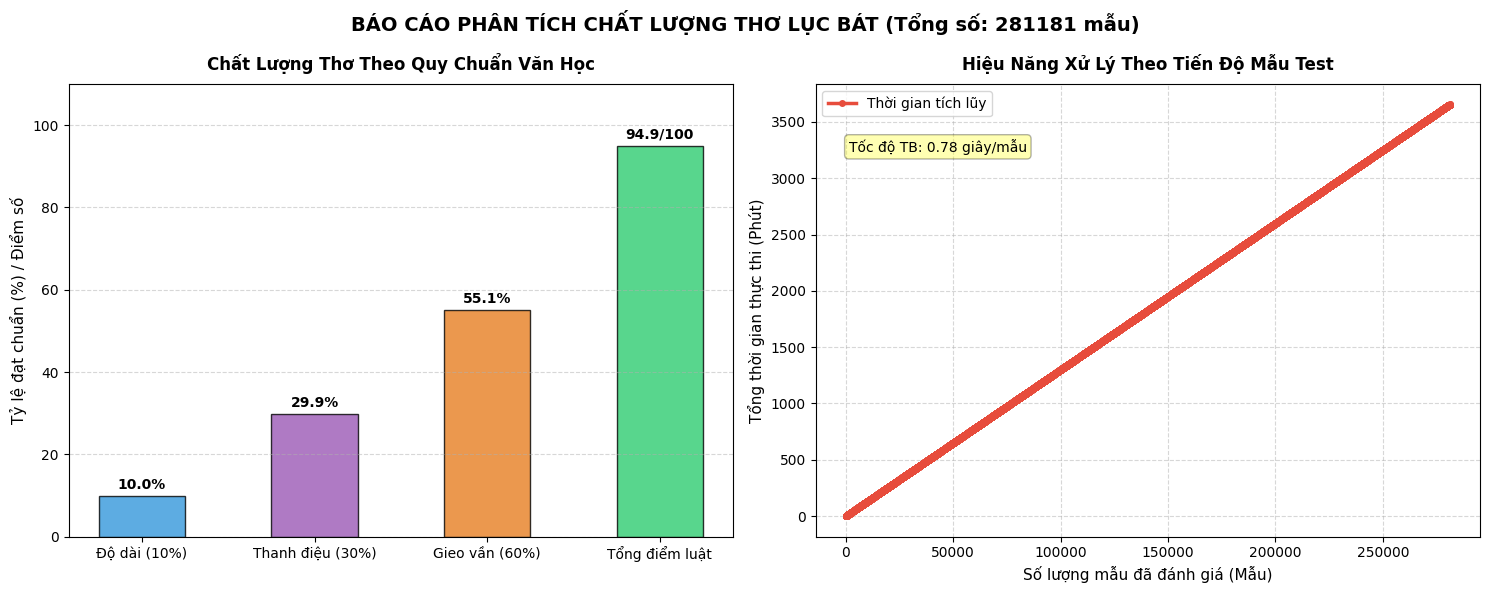

Đã vẽ xong đồ thị và lưu tệp hình ảnh độ phân giải cao tại: /content/drive/MyDrive/gen-poem/src/eval_chart.png


<Figure size 640x480 with 0 Axes>

In [6]:
%cd /content/drive/MyDrive/gen-poem/src
%run evaluate_chart.py